# Imports

In [ ]:
from spaghetti_code.old_spaghetti.compare_sparsity_LASSO import *

# Baseline in $\mathbb R^{3 \times 5}$
As a baseline, what is the performance of LASSO on a real valued underdetermined system $Y = AX$. It looks like SP (the sparse prior method) is worse on small systems

In [ ]:
X_TRUE, A, Y = initialize_underdetermined_system(num_mics=4, num_sources=5,  sparsity=2, amplitude=10, complex_valued=False, seed=2)
X0 = np.linalg.pinv(A) @ Y
X_lasso = complex_lasso(A, Y, alpha=1e-3)
X_sp, B = sparse_prior_solution(X0, A)
plot_equation(X_TRUE, A, Y, (r"$X_{True}$", "A", "Y"))
plot_equation(X0, X_lasso, X_sp, (r"$X_0$", r"$X_{LASSO}$", r"$X_{SP}$"))
# plot_equation(B, X_lasso.reshape(-1, 1) - X_TRUE.reshape(-1, 1), X_sp.reshape(-1, 1) - X_TRUE.reshape(-1, 1), (r"$B$", r"$X_{LASSO} - X_{True}$", r"$X_{SP} - X_{True}$"))

# Baseline in $\mathbb C^{3 \times 5}$

In [ ]:
X_TRUE, A, Y = initialize_underdetermined_system(num_mics=3, num_sources=5,  sparsity=2, amplitude=10, complex_valued=True, seed=2)
X0 = np.linalg.pinv(A) @ Y
X_lasso = complex_lasso(A, Y, alpha=0.001)
X_sp, B = sparse_prior_solution(X0, A)
plot_equation(X_TRUE, A, Y, (r"$X_{True}$", "A", "Y"))
plot_equation(X0, X_lasso, X_sp, (r"$X_0$", r"$X_{LASSO}$", r"$X_{SP}$"))

# Simulated data in $\mathbb C^{3 \times 5}$

In [ ]:
sim = run_simulation(num_mics=3, num_sources=5, s_sparse=2)
# plot_overview(sim)

freq_index = 1
Y = sim.Y[:, freq_index]  # Measurements
A = sim.C[:, :, freq_index]  # Mixing matrix
X0 = np.linalg.pinv(A) @ Y  # initial guess for X
X_TRUE = sim.X[:, freq_index]  # True source signals

X_sp, B = sparse_prior_solution(X0, A)
X_lasso = complex_lasso(A, Y, alpha=0.1)

# Compare solutions
plot_equation(X_TRUE, A, Y, (r"$X_{True}$", "A", "Y"))
plot_equation(X0, X_lasso, X_sp, (r"$X_0$", r"$X_{LASSO}$", r"$X_{SP}$"))


# Error count of nonzero values
Count the number of nonzero entries ( < 10\% of max_value)

In [ ]:
threshold = noise_threshold(Y, A, tolerance_factor=0.1)
nonzero_true = count_nonzero(X_TRUE, tol=threshold)
nonzero_sp = count_nonzero(X_sp, tol=threshold)
nonzero_lasso = count_nonzero(X_lasso, tol=threshold)

print(f"Number of non-zeros in True X: {nonzero_true}")
print(f"Number of non-zeros in Sparse Prior X: {nonzero_sp}")
print(f"Number of non-zeros in LASSO X: {nonzero_lasso}")

print()
print(f"Noise threshold: {threshold:.4f}")
print(f"Mistaken non-zeros of Sparse Prior X: {nonzero_difference(X_TRUE, X_sp, tol=threshold)}")
print(f"Mistaken non-zeros of LASSO X: {nonzero_difference(X_TRUE, X_lasso, tol=threshold)}")

# Compare sparsity for different setups

### How to read the plot

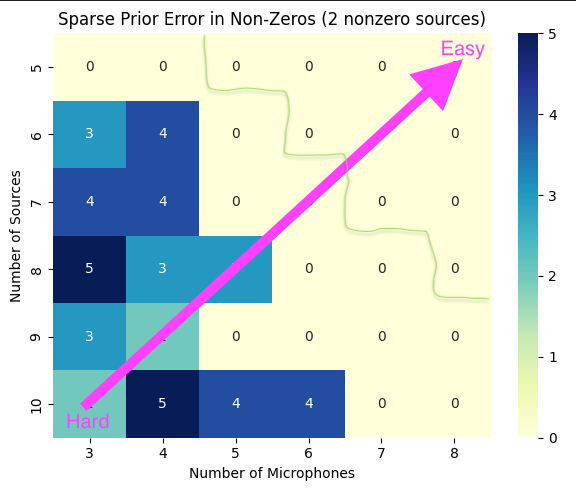

In [ ]:
num_mics_list = [3, 4, 5, 6, 7, 8]
num_sources_list = [5, 6, 7, 8, 9, 10]
s_sparse_list = [1,2,3,4,5]
alpha = 1e-3

results = run_comparison_sparsity(mic_range=num_mics_list, source_range=num_sources_list, sparsity_range=s_sparse_list, alpha=alpha)
heatmap_sparsity_comparison(results, s_sparse=1)
heatmap_sparsity_comparison(results, s_sparse=2)
heatmap_sparsity_comparison(results, s_sparse=3)
# heatmap_sparsity_comparison(results, s_sparse=4)
# heatmap_sparsity_comparison(results, s_sparse=5)

# Does LASSO find small sums instead of sparse solutions
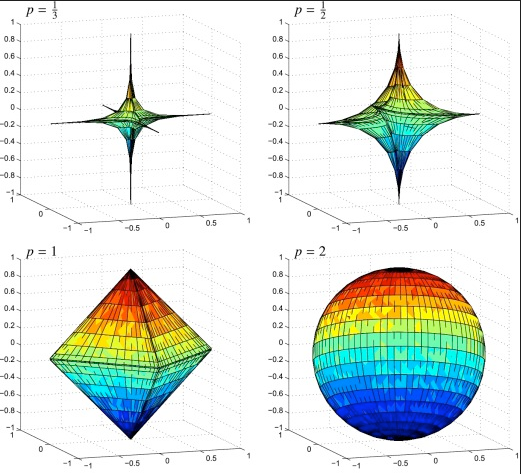

Scikit-learn uses coordinate descent on
$$ \min_X \; \frac{1} {2 \cdot n_{samples}} \cdot ||Y - AX||^2_{2} +  {\red \alpha}||X||_{1}$$
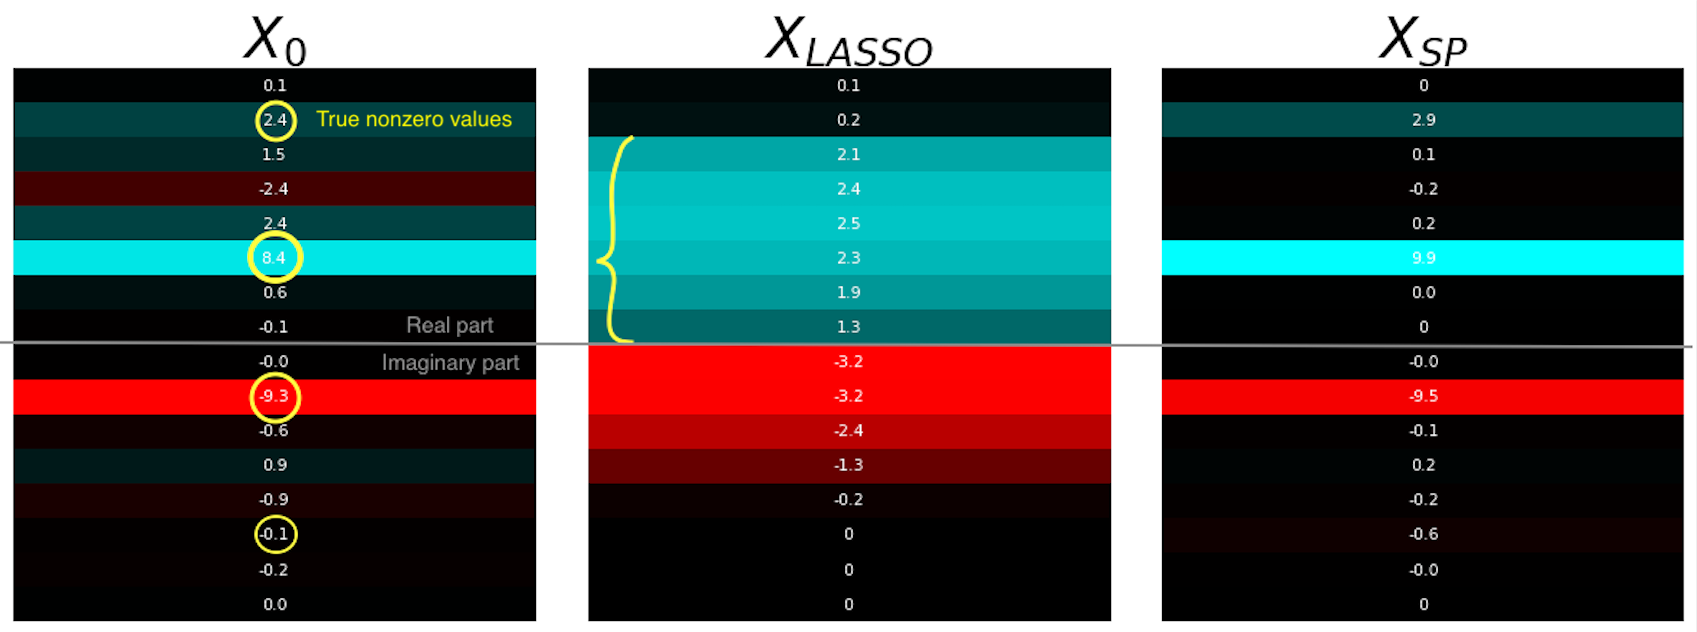

In [ ]:
alpha = 1e-3

Y, A, X0, X_TRUE = just_YAX_from_simulation(num_mics=7, num_sources=8, s_sparse=2)
X_lasso = complex_lasso(A, Y, alpha=alpha)
X_sp, B = sparse_prior_solution(X0, A)
plot_equation(X_TRUE, A, Y, (r"$X_{True}$", "A", "Y"))
plot_equation(X0, X_lasso, X_sp, (r"$X_0$", r"$X_{LASSO}$", r"$X_{SP}$"))

# real valued
X_lasso_real = to_real_augmented(X_lasso)
X_sp_real = to_real_augmented(X_sp)
X_TRUE_real = to_real_augmented(X_TRUE)
X0_real = to_real_augmented(X0)
A_real = to_real_augmented(A)
Y_real = to_real_augmented(Y)
plot_equation(X_TRUE_real, A_real, Y_real, (r"$X_{True}$", "A", "Y"))
plot_equation(X0_real, X_lasso_real, X_sp_real, (r"$X_0$", r"$X_{LASSO}$", r"$X_{SP}$"))



Phase difference